<a href="https://colab.research.google.com/github/grupos4g4/PROJAPLIC4/blob/main/analise_inicial_dados_inep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
arquivos = [
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2013.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2014.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2015.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2016.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2017.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2018.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2019.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2020.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2021.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2022.CSV",
    "/content/drive/MyDrive/Projeto Aplicado 4/microdados_cadastro_cursos/MICRODADOS_CADASTRO_CURSOS_2023.CSV",
]

# Colunas de interesse
colunas = [
    "NU_ANO_CENSO", "TP_MODALIDADE_ENSINO",
    "QT_MAT", "QT_CONC",
    "QT_SIT_TRANCADA", "QT_SIT_DESVINCULADO"
]

dados_resumidos = []

In [ ]:
# Colunas necessárias
colunas = ["NU_ANO_CENSO","TP_MODALIDADE_ENSINO","QT_MAT","QT_SIT_TRANCADA","QT_SIT_DESVINCULADO"]

resumos = []

for arq in arquivos:
    df = pd.read_csv(arq, sep=";", encoding="latin1", usecols=colunas, low_memory=False)

    # Agregar por ano e modalidade (1 = Presencial, 2 = EAD)
    resumo = df.groupby(["NU_ANO_CENSO","TP_MODALIDADE_ENSINO"])[["QT_MAT","QT_SIT_TRANCADA","QT_SIT_DESVINCULADO"]].sum()

    # Calcular taxa de evasão
    resumo["TX_EVASAO"] = ((resumo["QT_SIT_TRANCADA"] + resumo["QT_SIT_DESVINCULADO"]) / resumo["QT_MAT"]) * 100

    resumos.append(resumo)

# Concatenar todos os anos
serie = pd.concat(resumos).reset_index()

# Separar presencial e EAD
serie_presencial = serie[serie["TP_MODALIDADE_ENSINO"] == 1]
serie_ead = serie[serie["TP_MODALIDADE_ENSINO"] == 2]

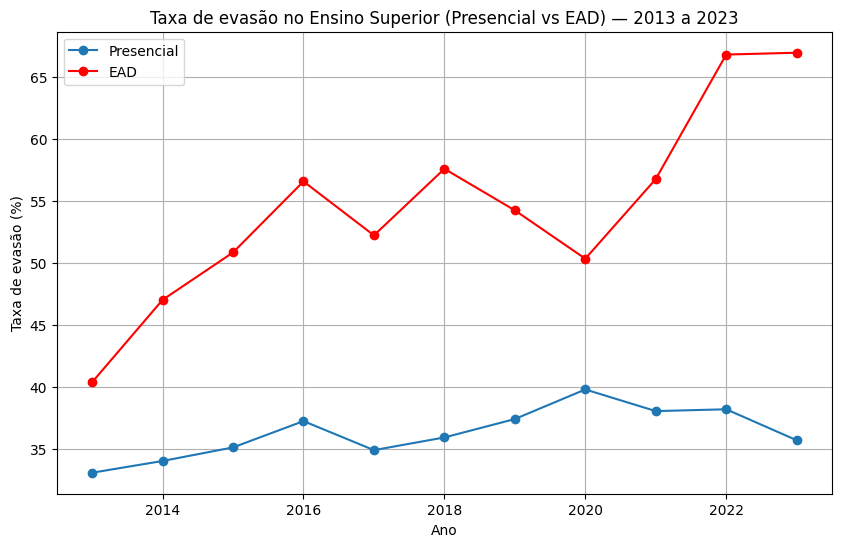

TP_MODALIDADE_ENSINO          1          2
NU_ANO_CENSO                              
2013                  33.111278  40.402465
2014                  34.057338  47.035792
2015                  35.149419  50.853578
2016                  37.268793  56.573590
2017                  34.931145  52.230269
2018                  35.952620  57.590373
2019                  37.436696  54.244378
2020                  39.817802  50.350908
2021                  38.074581  56.768217
2022                  38.221209  66.794645
2023                  35.726913  66.941805


In [ ]:
plt.figure(figsize=(10,6))
plt.plot(serie_presencial["NU_ANO_CENSO"], serie_presencial["TX_EVASAO"], marker="o", label="Presencial")
plt.plot(serie_ead["NU_ANO_CENSO"], serie_ead["TX_EVASAO"], marker="o", label="EAD", color="red")

plt.xlabel("Ano")
plt.ylabel("Taxa de evasão (%)")
plt.title("Taxa de evasão no Ensino Superior (Presencial vs EAD) — 2013 a 2023")
plt.legend()
plt.grid(True)
plt.show()

print(serie.pivot(index="NU_ANO_CENSO", columns="TP_MODALIDADE_ENSINO", values="TX_EVASAO"))